<a href="https://colab.research.google.com/github/Tanman005/RAG_CHATBOT/blob/main/rag_chatbot_dev.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RAG Chatbot — End-to-End Capstone Project

A Retrieval-Augmented Generation chatbot that answers questions grounded in web pages you provide. Unlike a plain LLM chat, every answer here is backed by retrieved source content — and every answer shows which URLs it drew from.

**Stack:** LangChain · ChromaDB · Groq (`llama-3.1-8b-instant`) · Sentence-Transformers (local embeddings) · Streamlit

**What this notebook does, end to end:**
1. Scrape and load web pages
2. Chunk and embed the content
3. Build a persistent vector store
4. Retrieve + generate answers via Groq, with conversational memory
5. **Refine** the knowledge base by adding new URLs later, without rebuilding from scratch
6. Evaluate retrieval and answer quality with a real test set
7. Generate the standalone `rag_pipeline.py` and `app.py` project files
8. Launch the Streamlit app directly from Colab for a live demo

This notebook and `app.py` share the exact same pipeline code (`rag_pipeline.py`) — nothing is duplicated or reimplemented differently between development and production.

## 1. Environment Setup

Following the established session workflow: mount Drive → `os.chdir()` → installs, before any imports.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

PROJECT_DIR = '/content/drive/MyDrive/rag_chatbot_project'
os.makedirs(PROJECT_DIR, exist_ok=True)
os.chdir(PROJECT_DIR)
print("Working directory:", os.getcwd())

Working directory: /content/drive/MyDrive/rag_chatbot_project


In [3]:
!pip install -q langchain langchain-community langchain-groq chromadb sentence-transformers streamlit python-dotenv beautifulsoup4 pyngrok

## 2. Configuration

Your Groq API key never gets typed in plain text into a cell — it's read from Colab's Secrets manager. Get a free key at [console.groq.com](https://console.groq.com).

**Setup:** click the key icon 🔑 in the left sidebar → Add new secret → Name: `GROQ_API_KEY` → paste your key → toggle Notebook access ON.

In [34]:
from google.colab import userdata

GROQ_API_KEY = userdata.get('GROQ_API_KEY')
os.environ['GROQ_API_KEY'] = GROQ_API_KEY
print("Groq API key loaded.")

Groq API key loaded.


## 3. Write `rag_pipeline.py`

This is the shared core module — the notebook imports it below, and it's also the exact file `app.py` imports. Writing it here (rather than just describing it) means running this notebook regenerates the whole project from scratch on any machine.

In [44]:
!pip install -q langchain-huggingface

In [45]:
%%writefile rag_pipeline.py
"""
rag_pipeline.py

Core RAG (Retrieval-Augmented Generation) logic shared between the development
notebook and the Streamlit app. Keeping this in one module means the notebook
and the app can never drift out of sync with each other.

Pipeline: URLs -> scrape -> chunk -> embed -> vector store (Chroma) -> retrieve -> Groq LLM -> answer
"""

import os
import torch
import requests
from bs4 import BeautifulSoup
from typing import List, Optional

from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_groq import ChatGroq
from langchain_classic.chains import ConversationalRetrievalChain
from langchain_classic.memory import ConversationBufferMemory


EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
DEFAULT_PERSIST_DIR = "chroma_db"
DEFAULT_LLM_MODEL = "llama-3.1-8b-instant"


def load_documents_from_urls(urls: List[str], verbose: bool = True):
    documents = []
    failed = []
    headers = {"User-Agent": "Mozilla/5.0 (RAG-Chatbot-Capstone/1.0)"}

    for url in urls:
        url = url.strip()
        if not url:
            continue
        try:
            response = requests.get(url, headers=headers, timeout=15)
            response.raise_for_status()
            soup = BeautifulSoup(response.content, "html.parser")

            paragraphs = soup.find_all("p")
            text = "\n\n".join(
                p.get_text(separator=" ", strip=True)
                for p in paragraphs
                if len(p.get_text(strip=True)) > 40
            )

            if not text.strip():
                raise ValueError("No substantial paragraph text found on page")

            documents.append(Document(page_content=text, metadata={"source": url}))
            if verbose:
                print(f"  Loaded: {url}  ({len(text)} chars)")
        except Exception as e:
            failed.append((url, str(e)))
            if verbose:
                print(f"  FAILED: {url}  -> {e}")

    if verbose:
        print(f"\nLoaded {len(documents)} document(s), {len(failed)} failure(s).")

    return documents, failed


def split_documents(documents, chunk_size: int = 1000, chunk_overlap: int = 150):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=["\n\n", "\n", ". ", " ", ""],
    )
    return splitter.split_documents(documents)


def get_embedding_model():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    return HuggingFaceEmbeddings(
        model_name=EMBEDDING_MODEL,
        model_kwargs={"device": device},
        encode_kwargs={"batch_size": 32, "normalize_embeddings": True},
    )


def build_vectorstore(chunks, persist_directory: str = DEFAULT_PERSIST_DIR):
    embeddings = get_embedding_model()
    # Chroma auto-persists as of 0.4.x - no manual .persist() call needed
    return Chroma.from_documents(
        documents=chunks,
        embedding=embeddings,
        persist_directory=persist_directory,
    )


def load_vectorstore(persist_directory: str = DEFAULT_PERSIST_DIR):
    embeddings = get_embedding_model()
    return Chroma(persist_directory=persist_directory, embedding_function=embeddings)


def add_urls_to_vectorstore(urls: List[str], vectorstore, chunk_size: int = 1000, chunk_overlap: int = 150):
    documents, failed = load_documents_from_urls(urls)
    if not documents:
        return vectorstore, failed
    chunks = split_documents(documents, chunk_size, chunk_overlap)
    vectorstore.add_documents(chunks)
    return vectorstore, failed


def get_qa_chain(vectorstore, groq_api_key: str, model_name: str = DEFAULT_LLM_MODEL, k: int = 4):
    llm = ChatGroq(groq_api_key=groq_api_key, model_name=model_name, temperature=0.2)
    memory = ConversationBufferMemory(memory_key="chat_history", return_messages=True, output_key="answer")
    retriever = vectorstore.as_retriever(search_kwargs={"k": k})
    return ConversationalRetrievalChain.from_llm(
        llm=llm, retriever=retriever, memory=memory, return_source_documents=True,
    )


def ask(chain, question: str):
    result = chain.invoke({"question": question})
    answer = result["answer"]
    sources = sorted(set(
        doc.metadata.get("source", "unknown") for doc in result.get("source_documents", [])
    ))
    return answer, sources

Overwriting rag_pipeline.py


In [46]:
import rag_pipeline
import importlib
importlib.reload(rag_pipeline)
from rag_pipeline import (
    load_documents_from_urls, split_documents, get_embedding_model,
    build_vectorstore, load_vectorstore, add_urls_to_vectorstore,
    get_qa_chain, ask, DEFAULT_PERSIST_DIR
)
print("rag_pipeline imported successfully.")

rag_pipeline imported successfully.


## 4. Load Web Pages

Replace these with any URLs you want the chatbot to know about. A small mixed set is used here as a working example — swap freely.

In [23]:
urls = [
    "https://en.wikipedia.org/wiki/Retrieval-augmented_generation",
    "https://en.wikipedia.org/wiki/Large_language_model",
    "https://en.wikipedia.org/wiki/Vector_database",
]

documents, failed_urls = load_documents_from_urls(urls)

if failed_urls:
    print("\nThe following URLs failed to load:")
    for url, err in failed_urls:
        print(f"  {url}: {err}")

  Loaded: https://en.wikipedia.org/wiki/Retrieval-augmented_generation  (8856 chars)
  Loaded: https://en.wikipedia.org/wiki/Large_language_model  (50362 chars)
  Loaded: https://en.wikipedia.org/wiki/Vector_database  (3047 chars)

Loaded 3 document(s), 0 failure(s).


## 5. Explore the Scraped Content

Before embedding anything, a quick sanity check on what was actually scraped — length, source balance, and a peek at the raw text.

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

doc_info = pd.DataFrame({
    'source': [d.metadata.get('source', 'unknown') for d in documents],
    'char_count': [len(d.page_content) for d in documents],
})
doc_info

,source,char_count
0,https://en.wikipedia.org/wiki/Retrieval-augmen...,8856
1,https://en.wikipedia.org/wiki/Large_language_m...,50362
2,https://en.wikipedia.org/wiki/Vector_database,3047


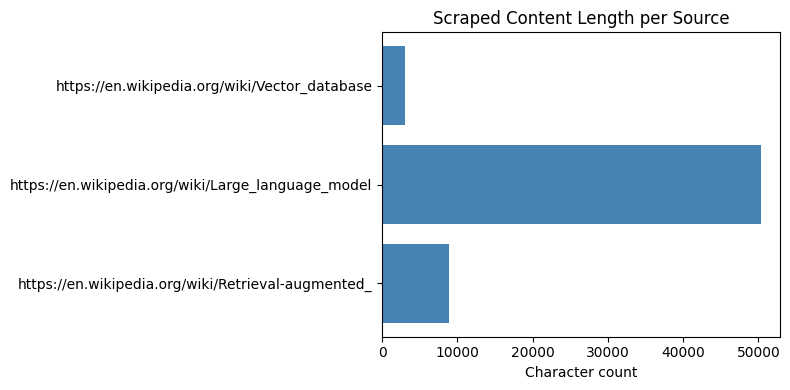

In [25]:
plt.figure(figsize=(8, 4))
plt.barh(doc_info['source'].str.slice(0, 50), doc_info['char_count'], color='steelblue')
plt.xlabel("Character count")
plt.title("Scraped Content Length per Source")
plt.tight_layout()
plt.show()

In [26]:
print("Preview of first document:\n")
print(documents[0].page_content[:500], "...")

Preview of first document:

Retrieval-augmented generation ( RAG ) is a technique that enables large language models (LLMs) to retrieve and incorporate new information from external data sources. [ 1 ] With RAG, LLMs first refer to a specified set of documents, then respond to user queries. These documents supplement information from the LLM's pre-existing training data . [ 2 ] This allows LLMs to use domain-specific and/or updated information that is not available in the training data. [ 2 ] For example, this enables LLM- ...


## 6. Chunking

Documents are split into overlapping chunks (1000 chars, 150 overlap) — small enough for precise retrieval, with enough overlap that an answer split across a chunk boundary isn't lost.

3 document(s) split into 90 chunks.


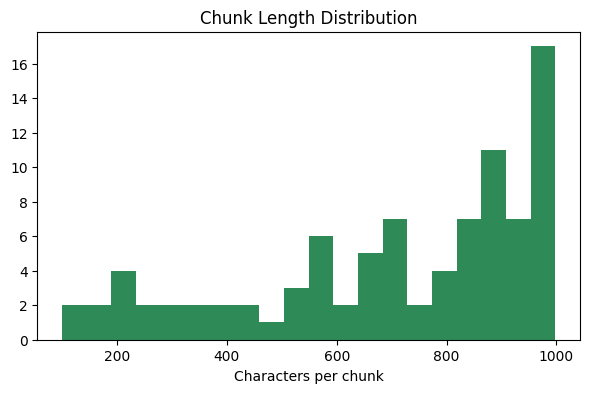

In [27]:
chunks = split_documents(documents, chunk_size=1000, chunk_overlap=150)
print(f"{len(documents)} document(s) split into {len(chunks)} chunks.")

chunk_lengths = [len(c.page_content) for c in chunks]
plt.figure(figsize=(7, 4))
plt.hist(chunk_lengths, bins=20, color='seagreen')
plt.title("Chunk Length Distribution")
plt.xlabel("Characters per chunk")
plt.show()

## 7. Build the Vector Store

Embeds all chunks in batches (not one at a time — this is what caused the slow, unresponsive embedding step in an earlier CPU-only run) and persists the result to Drive so it survives across sessions.

In [28]:
import time

print("Building vector store...")

start = time.time()
vectorstore = build_vectorstore(chunks, persist_directory=DEFAULT_PERSIST_DIR)
elapsed = time.time() - start

print(f"Vector store built and persisted in {elapsed:.1f}s.")

Building vector store...


/content/drive/MyDrive/rag_chatbot_project/rag_pipeline.py:84: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  return HuggingFaceEmbeddings(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Vector store built and persisted in 25.8s.


/content/drive/MyDrive/rag_chatbot_project/rag_pipeline.py:98: LangChainDeprecationWarning: Since Chroma 0.4.x the manual persistence method is no longer supported as docs are automatically persisted.
  vectorstore.persist()


## 8. Test Retrieval

Before involving the LLM at all, confirm the retriever actually pulls relevant chunks for a query. This isolates retrieval quality from generation quality — if retrieval is bad here, no amount of prompting will fix the final answers.

In [29]:
test_query = "What is retrieval-augmented generation?"
retrieved = vectorstore.similarity_search(test_query, k=3)

for i, doc in enumerate(retrieved):
    print(f"--- Result {i+1} (source: {doc.metadata.get('source')}) ---")
    print(doc.page_content[:300], "...\n")

--- Result 1 (source: https://en.wikipedia.org/wiki/Retrieval-augmented_generation) ---
The term retrieval-augmented generation (RAG) was introduced in a 2020 paper that described combining a parametric language model with a non-parametric external memory accessed through retrieval at inference time. [ 3 ] ...

--- Result 2 (source: https://en.wikipedia.org/wiki/Large_language_model) ---
Retrieval-augmented generation (RAG) is an approach that integrates LLMs with document retrieval systems. Given a query, a document retriever is called to retrieve the most relevant documents. This is usually done by encoding the query and the documents into vectors, then finding the documents with  ...

--- Result 3 (source: https://en.wikipedia.org/wiki/Retrieval-augmented_generation) ---
Retrieval-augmented generation (RAG) enhances large language models (LLMs) by incorporating an information-retrieval mechanism that allows models to access and utilize additional data beyond their original training 

## 9. Build the Conversational RAG Chain

Combines the retriever with the Groq LLM, plus conversation memory so follow-up questions ("what about its downsides?") resolve correctly using prior chat context.

In [36]:
chain = get_qa_chain(vectorstore, groq_api_key=GROQ_API_KEY, model_name='llama-3.1-8b-instant', k=4)
print("Conversational RAG chain ready.")

Conversational RAG chain ready.


## 10. Ask Questions

In [37]:
# Follow-up question - tests whether conversational memory correctly resolves "it"
answer, sources = ask(chain, "What are its main limitations?")
print("Answer:\n", answer)
print("\nSources used:", sources)

Answer:
 Based on the provided context, the main limitations of large language models (LLMs) include:

1. **Energy demands and environmental impact**: The energy consumption of LLMs is substantial, and much of it is generated by non-renewable resources, contributing to greenhouse gas emissions and climate change.

2. **Memorization and copyright leakage**: LLMs can memorize large amounts of data, including copyrighted materials, which can lead to copyright leakage and potential legal issues.

3. **Security exploits**: LLMs are vulnerable to security exploits, such as prompt injection, which can be used to manipulate or deceive the model.

4. **Algorithmic bias and stereotyping**: LLMs can perpetuate existing biases and stereotypes present in the data used to train them, leading to unfair or discriminatory outcomes.

5. **Dataset selection effects and political skew**: The choice of dataset used to train LLMs can influence the model's performance and bias, potentially leading to politic

## 11. Refine the Knowledge Base

Add more URLs *without* rebuilding the whole vector store from scratch — this is the incremental refinement workflow the app supports too.

In [38]:
new_urls = ["https://en.wikipedia.org/wiki/Prompt_engineering"]

vectorstore, failed = add_urls_to_vectorstore(new_urls, vectorstore)
chain = get_qa_chain(vectorstore, groq_api_key=GROQ_API_KEY)  # rebuild chain on the refined store

answer, sources = ask(chain, "What is prompt engineering?")
print("Answer:\n", answer)
print("\nSources used:", sources)

  Loaded: https://en.wikipedia.org/wiki/Prompt_engineering  (17548 chars)

Loaded 1 document(s), 0 failure(s).
Answer:
 Prompt engineering is the process of formulating and refining prompts for an artificial intelligence program, algorithm, etc., in order to optimize its output or to achieve a desired outcome. It involves structuring natural language inputs to produce specified outputs from a generative artificial intelligence (GenAI) model.

Sources used: ['https://en.wikipedia.org/wiki/Prompt_engineering']


## 12. Evaluation

Rather than just eyeballing a few answers, this checks the pipeline against a small labeled test set: for each question, does the retrieved source match what's *expected*, and does the answer contain the *expected keyword(s)*? This gives an actual accuracy number instead of a vibe.

In [39]:
test_set = [
    {
        "question": "What is a vector database used for?",
        "expected_keywords": ["vector", "embedding", "similarity"],
        "expected_source_contains": "Vector_database",
    },
    {
        "question": "What is a large language model?",
        "expected_keywords": ["language model", "text"],
        "expected_source_contains": "Large_language_model",
    },
    {
        "question": "What is prompt engineering?",
        "expected_keywords": ["prompt"],
        "expected_source_contains": "Prompt_engineering",
    },
]

def evaluate(test_set, chain):
    results = []
    for case in test_set:
        answer, sources = ask(chain, case["question"])
        answer_lower = answer.lower()

        keyword_hit = any(kw.lower() in answer_lower for kw in case["expected_keywords"])
        source_hit = any(case["expected_source_contains"] in s for s in sources)

        results.append({
            "question": case["question"],
            "keyword_match": keyword_hit,
            "correct_source_retrieved": source_hit,
        })
    return pd.DataFrame(results)

eval_df = evaluate(test_set, chain)
eval_df

,question,keyword_match,correct_source_retrieved
0,What is a vector database used for?,True,True
1,What is a large language model?,True,True
2,What is prompt engineering?,True,True


In [40]:
keyword_accuracy = eval_df['keyword_match'].mean()
retrieval_accuracy = eval_df['correct_source_retrieved'].mean()

print(f"Keyword match rate     : {keyword_accuracy:.0%}")
print(f"Correct source retrieved: {retrieval_accuracy:.0%}")

Keyword match rate     : 100%
Correct source retrieved: 100%


**Reading these numbers:** `correct_source_retrieved` isolates the retriever's performance — it's checking whether the vector search found the right page, independent of what the LLM said with it. `keyword_match` is a rough proxy for answer quality (a real evaluation would use an LLM-as-judge or human review, but this keyword check is a reasonable and cheap signal at this scale).

## 13. Write `app.py`

The production Streamlit app — same `rag_pipeline.py` module, wrapped in a chat UI with a sidebar for building and refining the knowledge base.

In [41]:
%%writefile app.py
"""
app.py

Streamlit front-end for the RAG chatbot. Lets a user paste in URLs to build
a knowledge base, refine it by adding more URLs later, and chat with an
LLM (Groq) that answers grounded in the scraped content — with sources shown.

Run locally with:
    streamlit run app.py

Run from Colab (no native Streamlit hosting there) using pyngrok — see the
notebook's final section for that setup.
"""

import os
import streamlit as st
from dotenv import load_dotenv

from rag_pipeline import (
    load_documents_from_urls,
    split_documents,
    build_vectorstore,
    load_vectorstore,
    add_urls_to_vectorstore,
    get_qa_chain,
    ask,
    DEFAULT_PERSIST_DIR,
)

load_dotenv()

st.set_page_config(page_title="RAG Chatbot", page_icon="💬", layout="wide")


# ---------------------------------------------------------------------------
# Session state initialization
# ---------------------------------------------------------------------------
if "vectorstore" not in st.session_state:
    st.session_state.vectorstore = None
if "chain" not in st.session_state:
    st.session_state.chain = None
if "chat_history" not in st.session_state:
    st.session_state.chat_history = []  # list of (role, content, sources)
if "sources_used" not in st.session_state:
    st.session_state.sources_used = []  # all URLs ever added


# ---------------------------------------------------------------------------
# Sidebar — knowledge base setup
# ---------------------------------------------------------------------------
with st.sidebar:
    st.header("Knowledge Base")

    groq_api_key = st.text_input(
        "Groq API Key",
        value=os.getenv("GROQ_API_KEY", ""),
        type="password",
        help="Get a free key at console.groq.com",
    )

    url_input = st.text_area(
        "Paste URLs (one per line)",
        height=150,
        placeholder="https://example.com/article-1\nhttps://example.com/article-2",
    )

    col1, col2 = st.columns(2)

    with col1:
        build_clicked = st.button("Build Knowledge Base", use_container_width=True)
    with col2:
        refine_clicked = st.button("Add / Refine", use_container_width=True, disabled=st.session_state.vectorstore is None)

    st.divider()

    if os.path.exists(DEFAULT_PERSIST_DIR) and st.session_state.vectorstore is None:
        if st.button("Load existing knowledge base", use_container_width=True):
            with st.spinner("Loading saved knowledge base..."):
                st.session_state.vectorstore = load_vectorstore(DEFAULT_PERSIST_DIR)
                if groq_api_key:
                    st.session_state.chain = get_qa_chain(st.session_state.vectorstore, groq_api_key)
            st.success("Loaded.")

    if st.session_state.sources_used:
        st.subheader("Sources in knowledge base")
        for s in st.session_state.sources_used:
            st.caption(f"• {s}")

    st.divider()
    if st.button("Reset conversation", use_container_width=True):
        st.session_state.chat_history = []
        if st.session_state.vectorstore is not None and groq_api_key:
            st.session_state.chain = get_qa_chain(st.session_state.vectorstore, groq_api_key)
        st.rerun()


# ---------------------------------------------------------------------------
# Build / refine actions
# ---------------------------------------------------------------------------
urls = [u for u in url_input.split("\n") if u.strip()] if url_input else []

if build_clicked:
    if not groq_api_key:
        st.sidebar.error("Enter your Groq API key first.")
    elif not urls:
        st.sidebar.error("Paste at least one URL first.")
    else:
        with st.spinner(f"Scraping {len(urls)} URL(s) and building knowledge base..."):
            documents, failed = load_documents_from_urls(urls, verbose=False)
            if not documents:
                st.sidebar.error("Could not load any of the provided URLs.")
            else:
                chunks = split_documents(documents)
                st.session_state.vectorstore = build_vectorstore(chunks, DEFAULT_PERSIST_DIR)
                st.session_state.chain = get_qa_chain(st.session_state.vectorstore, groq_api_key)
                st.session_state.sources_used = list(set(st.session_state.sources_used + urls))
                st.session_state.chat_history = []
                if failed:
                    st.sidebar.warning(f"{len(failed)} URL(s) failed to load:\n" + "\n".join(u for u, _ in failed))
                st.sidebar.success(f"Knowledge base built from {len(documents)} page(s), {len(chunks)} chunks.")

if refine_clicked:
    if not urls:
        st.sidebar.error("Paste at least one URL to add first.")
    else:
        with st.spinner(f"Adding {len(urls)} URL(s) to the knowledge base..."):
            st.session_state.vectorstore, failed = add_urls_to_vectorstore(urls, st.session_state.vectorstore)
            st.session_state.chain = get_qa_chain(st.session_state.vectorstore, groq_api_key)
            st.session_state.sources_used = list(set(st.session_state.sources_used + urls))
            if failed:
                st.sidebar.warning(f"{len(failed)} URL(s) failed to load:\n" + "\n".join(u for u, _ in failed))
            st.sidebar.success("Knowledge base refined.")


# ---------------------------------------------------------------------------
# Main chat interface
# ---------------------------------------------------------------------------
st.title("💬 RAG Chatbot")
st.caption("Ask questions grounded in the web pages you've added to the knowledge base.")

if st.session_state.chain is None:
    st.info("Add URLs and click **Build Knowledge Base** in the sidebar to get started.")
else:
    for role, content, sources in st.session_state.chat_history:
        with st.chat_message(role):
            st.markdown(content)
            if sources:
                with st.expander("Sources"):
                    for s in sources:
                        st.caption(s)

    question = st.chat_input("Ask a question...")
    if question:
        st.session_state.chat_history.append(("user", question, None))
        with st.chat_message("user"):
            st.markdown(question)

        with st.chat_message("assistant"):
            with st.spinner("Thinking..."):
                answer, sources = ask(st.session_state.chain, question)
                st.markdown(answer)
                if sources:
                    with st.expander("Sources"):
                        for s in sources:
                            st.caption(s)

        st.session_state.chat_history.append(("assistant", answer, sources))


Writing app.py


## 14. Launch the App from Colab (demo purposes)

Colab can't natively host a Streamlit server, so `pyngrok` opens a temporary public tunnel to it. For anything beyond a live demo, deploy properly instead — see the note below.

In [48]:
from pyngrok import ngrok

# Get a free authtoken at https://dashboard.ngrok.com/get-started/your-authtoken
NGROK_AUTHTOKEN = userdata.get('NGROK_AUTHTOKEN')
ngrok.set_auth_token(NGROK_AUTHTOKEN)

In [49]:
import subprocess
import time

streamlit_process = subprocess.Popen(
    ["streamlit", "run", "app.py", "--server.port", "8501", "--server.headless", "true"]
)
time.sleep(5)

public_url = ngrok.connect(8501)
print("App is live at:", public_url)

App is live at: NgrokTunnel: "https://exclusion-bright-mongrel.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
# When you're done with the demo, shut it down cleanly:
# ngrok.disconnect(public_url.public_url)
# streamlit_process.terminate()

In [50]:
ngrok.disconnect(public_url.public_url)
streamlit_process.terminate()
print("Ngrok tunnel and Streamlit process stopped.")

Ngrok tunnel and Streamlit process stopped.
